# **Fingerprint Matching via Gabor Filters**
### Digital Image Processing-Project

---

## Project Overview

This project implements a complete Automatic Fingerprint Identification System (AFIS) using Gabor Filters for feature extraction and matching.

**Pipeline (each step processes ALL THREE images: Child, Father, Mother):**

| Step | Process |
|------|---------|
| 1 | Load Images |
| 2 | Histogram Equalization |
| 3 | Gaussian Smoothing |
| 4 | Gabor Filter Bank |
| 5 | Adaptive Binarization |
| 6 | Morphological Cleanup |
| 7 | Feature Extraction |
| 8 | Matching |

---
## Step 01: Install & Import Libraries

In [64]:
!pip install -q opencv-python-headless scikit-image matplotlib numpy Pillow scipy

In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from io import BytesIO
import requests, warnings
from scipy.ndimage import convolve, gaussian_filter
from skimage.morphology import erosion, dilation, skeletonize, disk
from skimage.filters import gabor_kernel

warnings.filterwarnings('ignore')

# Colour palette per subject
COLORS = {
    'Child_Sample1' : '#3498db',   # blue
    'Father_Sample1': '#e67e22',   # orange
    'Mother_Sample1': '#9b59b6',   # purple
}
NAMES = ['Child_Sample1', 'Father_Sample1', 'Mother_Sample1']

#  Utility: display a grid of images
def img_grid(images, titles=None, main_title='', cmap='gray', cols=4, figsize_per=(3, 3)):
    n = len(images)
    cols = min(cols, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(figsize_per[0]*cols, figsize_per[1]*rows))
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n:
            img = np.array(images[i]) if isinstance(images[i], Image.Image) else images[i]
            ax.imshow(img, cmap=cmap if img.ndim == 2 else None)
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=10)
            ax.axis('off')
        else:
            ax.axis('off')
    if main_title:
        fig.suptitle(main_title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Step 02: Load Fingerprint Images


 Loaded: Child_Sample1  shape=(192, 154)
 Loaded: Father_Sample1  shape=(192, 154)
 Loaded: Mother_Sample1  shape=(192, 154)


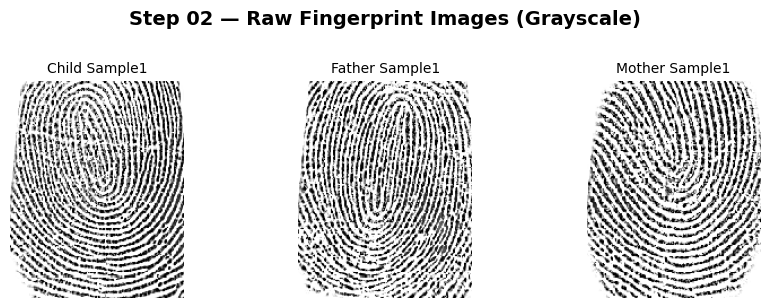


── Image Info ──
  Child_Sample1: shape=(192, 154), dtype=uint8, min=0, max=255
  Father_Sample1: shape=(192, 154), dtype=uint8, min=0, max=255
  Mother_Sample1: shape=(192, 154), dtype=uint8, min=0, max=255


In [67]:
FP_PATHS = {
    'Child_Sample1' : '/content/drive/MyDrive/CSE_438/project files/child.bmp',
    'Father_Sample1': '/content/drive/MyDrive/CSE_438/project files/father.bmp',
    'Mother_Sample1': '/content/drive/MyDrive/CSE_438/project files/mother.bmp',
}

def load_fingerprint(path):
    """Load fingerprint from local path → grayscale NumPy uint8 array."""
    img = Image.open(path).convert('L')
    return np.array(img, dtype=np.uint8)

#  Load ALL THREE images
fingerprints = {}
for name, path in FP_PATHS.items():
    try:
        fingerprints[name] = load_fingerprint(path)
        print(f' Loaded: {name}  shape={fingerprints[name].shape}')
    except Exception as e:
        print(f' Failed to load {name}: {e}')

#  Show all three raw images side by side
img_grid(
    [fingerprints[n] for n in NAMES],
    titles=[n.replace('_', ' ') for n in NAMES],
    main_title='Step 02 — Raw Fingerprint Images (Grayscale)',
    cols=3
)

print('\n── Image Info ──')
for name, img in fingerprints.items():
    print(f'  {name}: shape={img.shape}, dtype={img.dtype}, '
          f'min={img.min()}, max={img.max()}')

---
## Step 03: Histogram Analysis & Equalization


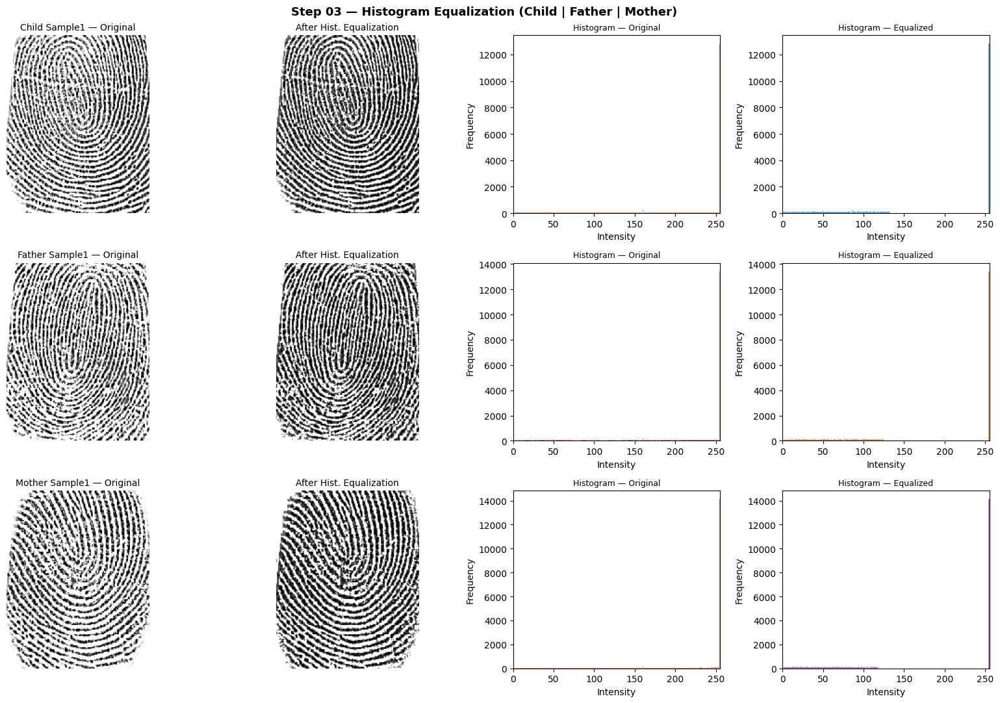

 Histogram equalization applied to Child, Father, and Mother.


In [68]:
def plot_histogram(img, ax, title='', color='steelblue'):
    ax.hist(img.flatten(), bins=256, range=(0, 255), color=color, alpha=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Frequency')
    ax.set_xlim([0, 255])

def histogram_equalization(img):
    """Manual histogram equalization (CDF-based LUT mapping)."""
    hist, _ = np.histogram(img.flatten(), 256, [0, 256])
    cdf     = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    N       = img.size
    lut = np.round((cdf - cdf_min) / (N - cdf_min) * 255).astype(np.uint8)
    return lut[img]

#  Apply histogram equalization to ALL THREE images
enhanced = {name: histogram_equalization(img) for name, img in fingerprints.items()}

#  Show Original vs Equalized + Histograms for ALL THREE
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for row, name in enumerate(NAMES):
    orig = fingerprints[name]
    eq   = enhanced[name]
    color = COLORS[name]

    axes[row, 0].imshow(orig, cmap='gray')
    axes[row, 0].set_title(f'{name.replace("_"," ")} — Original', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(eq, cmap='gray')
    axes[row, 1].set_title('After Hist. Equalization', fontsize=10)
    axes[row, 1].axis('off')

    plot_histogram(orig, axes[row, 2], 'Histogram — Original', color='tomato')
    plot_histogram(eq,   axes[row, 3], 'Histogram — Equalized', color=color)

fig.suptitle('Step 03 — Histogram Equalization (Child | Father | Mother)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(' Histogram equalization applied to Child, Father, and Mother.')

---
## Step 04: Noise Removal & Gaussian Smoothing


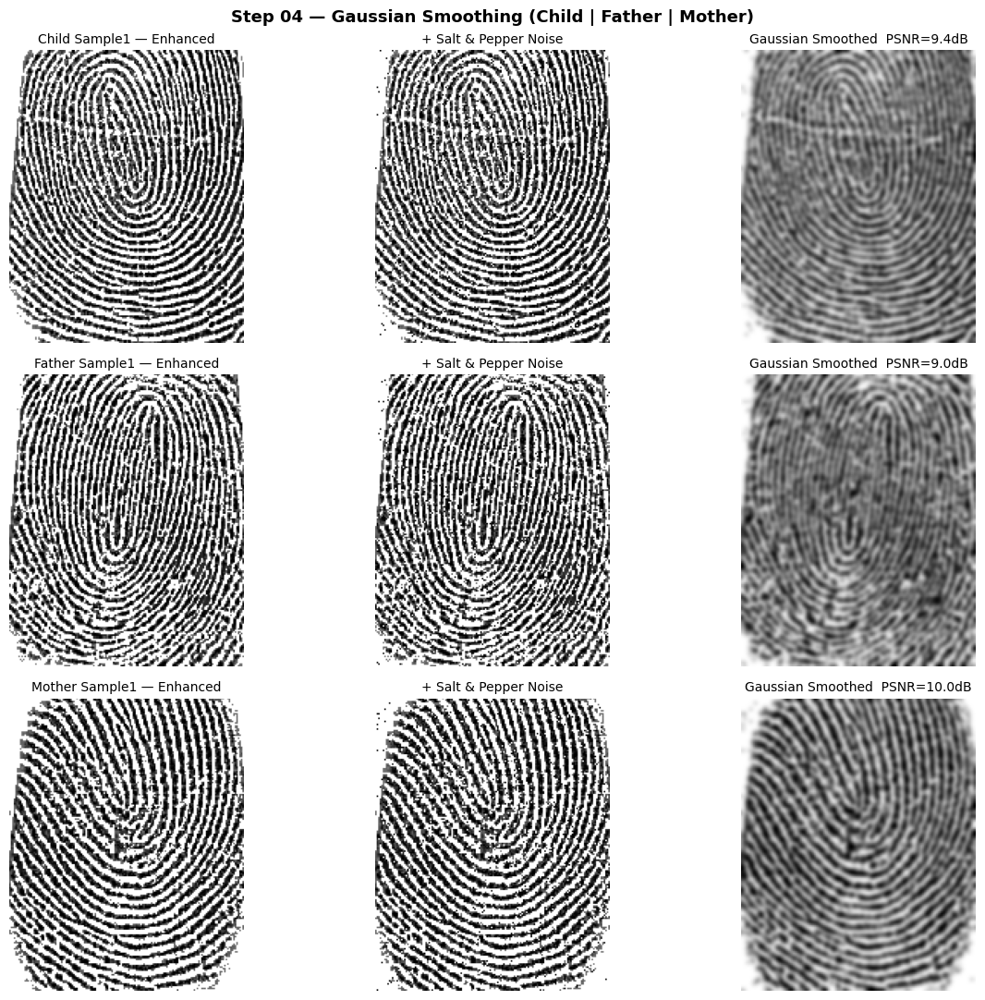

 Gaussian smoothing applied to Child, Father, and Mother.
  Child_Sample1: smoothed shape=(192, 154)
  Father_Sample1: smoothed shape=(192, 154)
  Mother_Sample1: smoothed shape=(192, 154)


In [69]:
def smooth_image(img, sigma=1.0):
    """Apply Gaussian smoothing to remove acquisition noise."""
    return gaussian_filter(img.astype(np.float64), sigma=sigma)

def add_salt_pepper(img, amount=0.03, seed=42):
    rng   = np.random.default_rng(seed)
    noisy = img.copy().astype(np.float64)
    mask  = rng.random(img.shape)
    noisy[mask < amount/2]     = 0
    noisy[mask > 1 - amount/2] = 255
    return noisy

def psnr(original, reconstructed):
    mse = np.mean((original.astype(float) - reconstructed.astype(float))**2)
    return float('inf') if mse == 0 else 20 * np.log10(255 / np.sqrt(mse))

#  Apply smoothing to ALL THREE enhanced images
smoothed = {name: smooth_image(img, sigma=1.0) for name, img in enhanced.items()}

#  Show Enhanced → Noisy → Smoothed for ALL THREE
fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for row, name in enumerate(NAMES):
    orig_f  = enhanced[name].astype(np.float64)
    noisy   = add_salt_pepper(orig_f, amount=0.04, seed=row)
    gauss_s = smooth_image(noisy, sigma=1.5)

    axes[row, 0].imshow(orig_f,  cmap='gray')
    axes[row, 0].set_title(f'{name.replace("_"," ")} — Enhanced',    fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(noisy,   cmap='gray')
    axes[row, 1].set_title('+ Salt & Pepper Noise', fontsize=10)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(gauss_s, cmap='gray')
    axes[row, 2].set_title(f'Gaussian Smoothed  PSNR={psnr(orig_f, gauss_s):.1f}dB',
                           fontsize=10)
    axes[row, 2].axis('off')

fig.suptitle('Step 04 — Gaussian Smoothing (Child | Father | Mother)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(' Gaussian smoothing applied to Child, Father, and Mother.')
for name in NAMES:
    print(f'  {name}: smoothed shape={smoothed[name].shape}')

---
## Step 05: Gabor Filter Bank


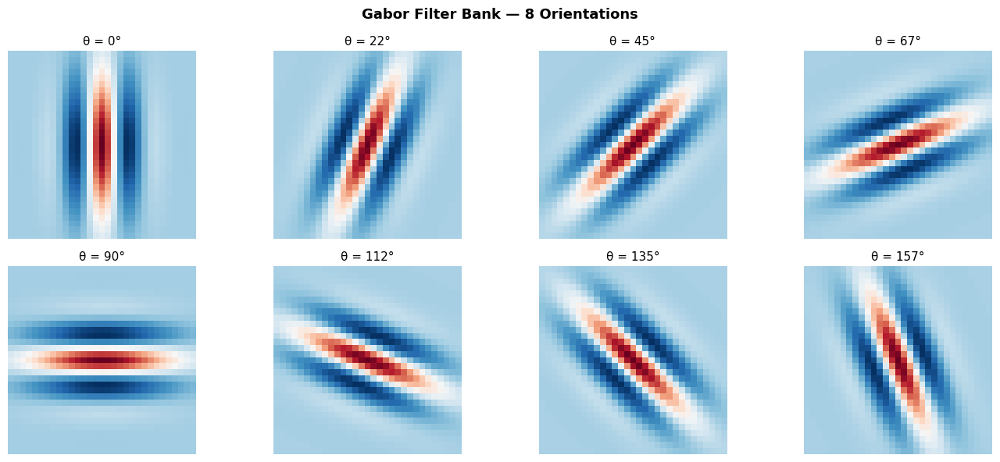

 Gabor applied: Child_Sample1
 Gabor applied: Father_Sample1
 Gabor applied: Mother_Sample1


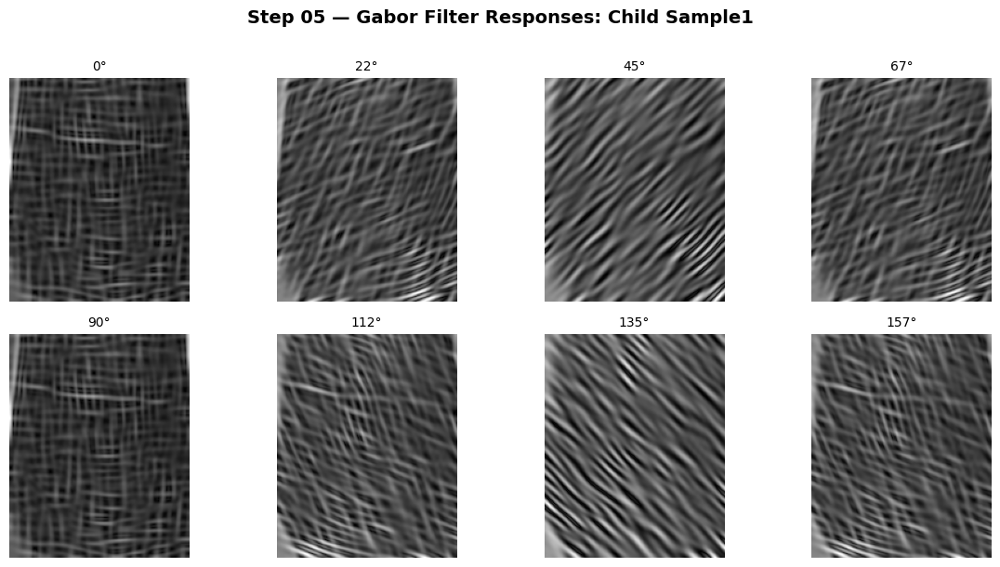

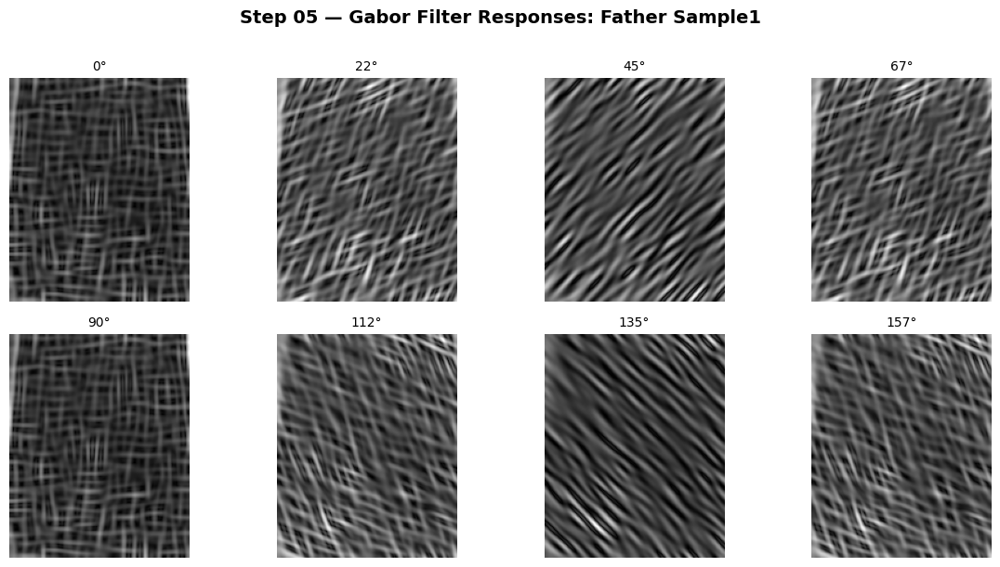

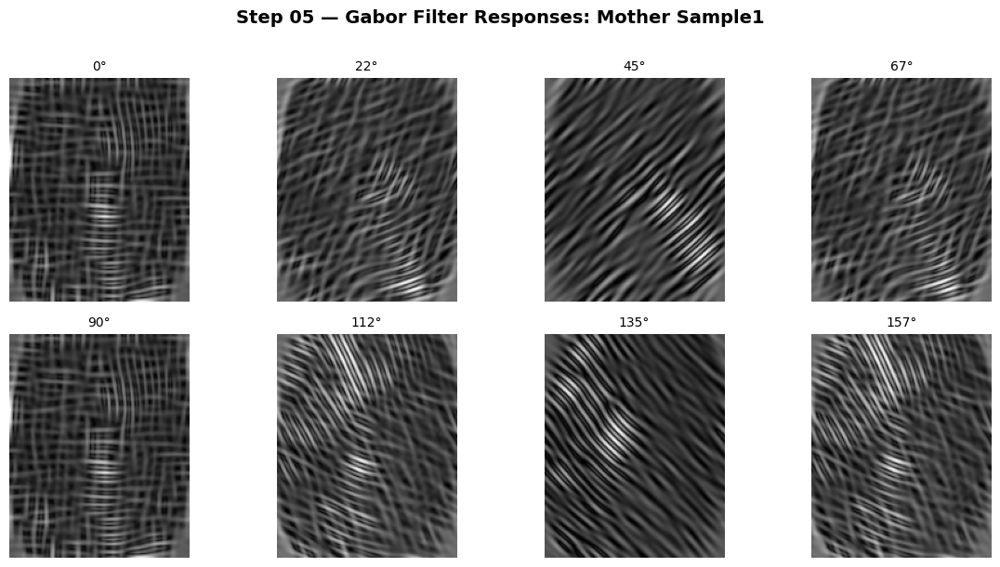

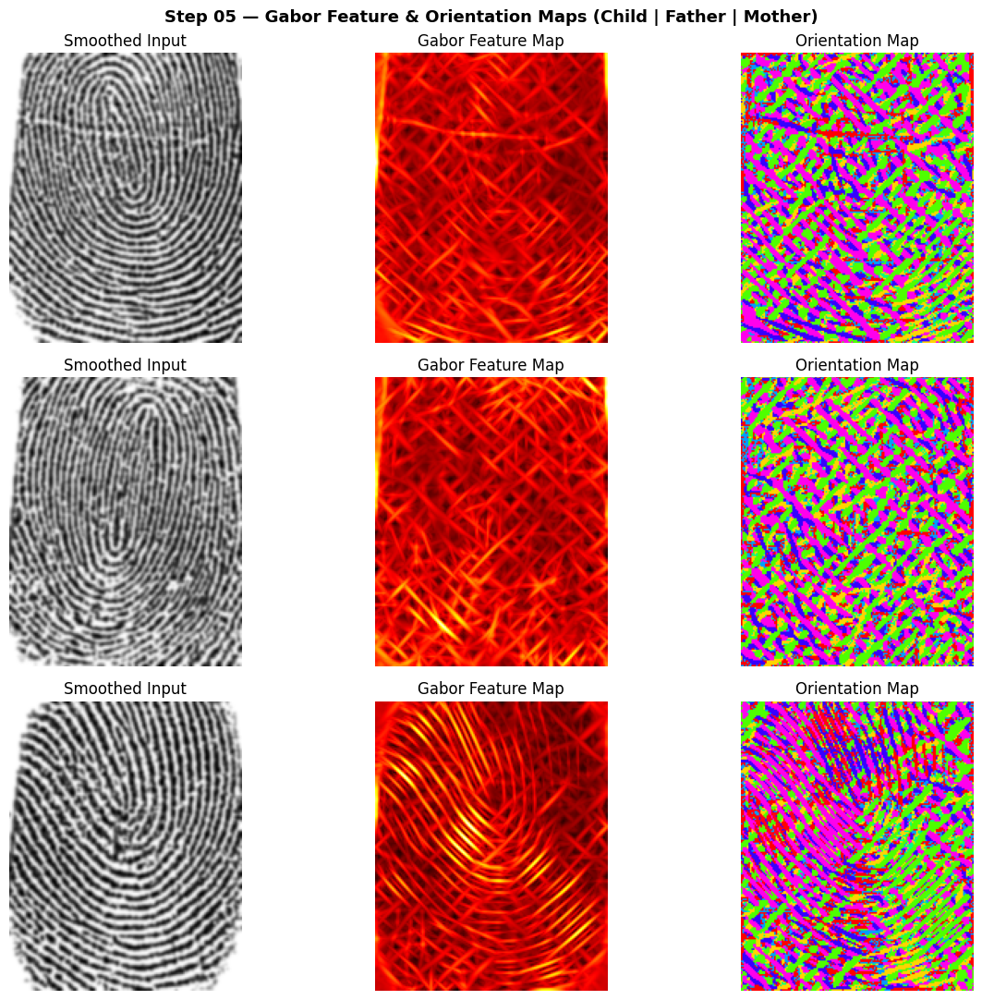

In [70]:
# 8 orientations: 0° to 157.5°
ORIENTATIONS = [i * np.pi / 8 for i in range(8)]
THETA_LABELS = [f'{int(t*180/np.pi)}°' for t in ORIENTATIONS]

def build_gabor_kernel_cv2(ksize=31, sigma=4.0, theta=0,
                            lambd=10.0, gamma=0.5, psi=0):
    return cv2.getGaborKernel(
        (ksize, ksize), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_64F
    )

def apply_gabor_bank(img, orientations=ORIENTATIONS,
                     sigma=4.0, lambd=10.0, gamma=0.5, ksize=31):
    """Apply 8-orientation Gabor bank; return (responses, feature_map, orient_map)."""
    img_f     = img.astype(np.float64)
    responses = []
    for theta in orientations:
        kern = build_gabor_kernel_cv2(ksize, sigma, theta, lambd, gamma)
        real = cv2.filter2D(img_f, cv2.CV_64F, kern)
        imag = cv2.filter2D(img_f, cv2.CV_64F, kern.T)
        responses.append(np.sqrt(real**2 + imag**2))
    stack         = np.stack(responses, axis=-1)
    feature_map   = np.max(stack,    axis=-1)
    orient_map    = np.argmax(stack, axis=-1)
    return responses, feature_map, orient_map

#  Visualise Gabor kernels (once)
kernels = [build_gabor_kernel_cv2(theta=t) for t in ORIENTATIONS]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, kern, lbl in zip(axes.flatten(), kernels, THETA_LABELS):
    ax.imshow(kern, cmap='RdBu_r')
    ax.set_title(f'θ = {lbl}', fontsize=11)
    ax.axis('off')
fig.suptitle('Gabor Filter Bank — 8 Orientations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#  Apply Gabor bank to ALL THREE smoothed images
gabor_results = {}
for name in NAMES:
    resp, feat_map, orient_map = apply_gabor_bank(smoothed[name])
    gabor_results[name] = {
        'responses'   : resp,
        'feature_map' : feat_map,
        'orient_map'  : orient_map,
    }
    print(f' Gabor applied: {name}')

#  Show Gabor responses for ALL THREE (one row per subject)
for name in NAMES:
    img_grid(
        gabor_results[name]['responses'],
        titles=THETA_LABELS,
        main_title=f'Step 05 — Gabor Filter Responses: {name.replace("_"," ")}'
    )

#  Show feature map + orientation map for ALL THREE
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for row, name in enumerate(NAMES):
    sm  = smoothed[name]
    fm  = gabor_results[name]['feature_map']
    om  = gabor_results[name]['orient_map']

    axes[row, 0].imshow(sm,  cmap='gray');  axes[row, 0].set_title('Smoothed Input'); axes[row, 0].axis('off')
    axes[row, 1].imshow(fm,  cmap='hot');   axes[row, 1].set_title('Gabor Feature Map'); axes[row, 1].axis('off')
    im = axes[row, 2].imshow(om, cmap='hsv')
    axes[row, 2].set_title('Orientation Map')
    axes[row, 2].axis('off')
    axes[row, 0].set_ylabel(name.replace('_', ' '), fontsize=10, fontweight='bold')

fig.suptitle('Step 05 — Gabor Feature & Orientation Maps (Child | Father | Mother)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 06: Binarization via Adaptive Thresholding


Binarized: Child_Sample1
Binarized: Father_Sample1
Binarized: Mother_Sample1


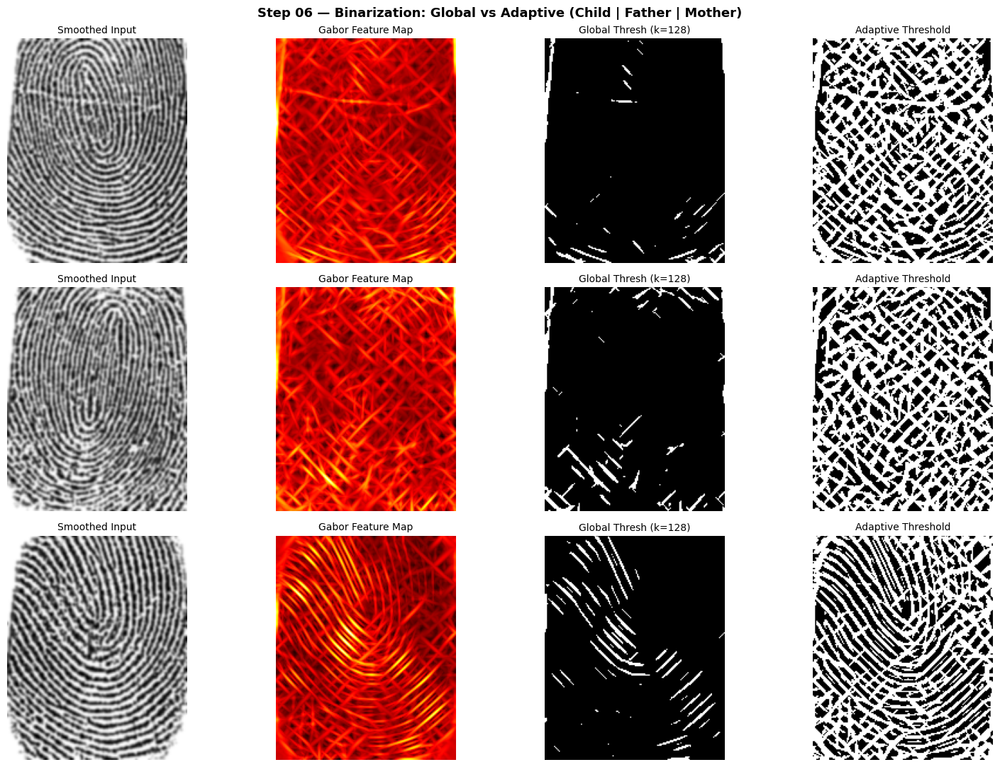

 Adaptive binarization complete for Child, Father, and Mother.


In [71]:
def binarize_fingerprint(feat_map, block_size=25, C=5):
    """Adaptive Gaussian thresholding on a Gabor feature map."""
    norm   = cv2.normalize(feat_map, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    binary = cv2.adaptiveThreshold(
        norm, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size, C
    )
    return binary

#  Apply binarization to ALL THREE feature maps
binary_maps = {}
for name in NAMES:
    feat_map = gabor_results[name]['feature_map']
    binary_maps[name] = binarize_fingerprint(feat_map)
    print(f'Binarized: {name}')

#  Show Gabor Feature Map → Global Threshold → Adaptive Threshold for ALL THREE
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for row, name in enumerate(NAMES):
    sm       = smoothed[name]
    feat_map = gabor_results[name]['feature_map']
    norm_f   = cv2.normalize(feat_map, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    glob_t   = (norm_f > 128).astype(np.uint8) * 255
    adap_t   = binary_maps[name]

    axes[row, 0].imshow(sm,      cmap='gray'); axes[row, 0].set_title('Smoothed Input',       fontsize=10); axes[row, 0].axis('off')
    axes[row, 1].imshow(feat_map,cmap='hot');  axes[row, 1].set_title('Gabor Feature Map',    fontsize=10); axes[row, 1].axis('off')
    axes[row, 2].imshow(glob_t,  cmap='gray'); axes[row, 2].set_title('Global Thresh (k=128)',fontsize=10); axes[row, 2].axis('off')
    axes[row, 3].imshow(adap_t,  cmap='gray'); axes[row, 3].set_title('Adaptive Threshold',   fontsize=10); axes[row, 3].axis('off')
    axes[row, 0].set_ylabel(name.replace('_', ' '), fontsize=10, fontweight='bold')

fig.suptitle('Step 06 — Binarization: Global vs Adaptive (Child | Father | Mother)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(' Adaptive binarization complete for Child, Father, and Mother.')

---
## Step 07: Morphological Post-Processing


Morphological processing done: Child_Sample1
Morphological processing done: Father_Sample1
Morphological processing done: Mother_Sample1


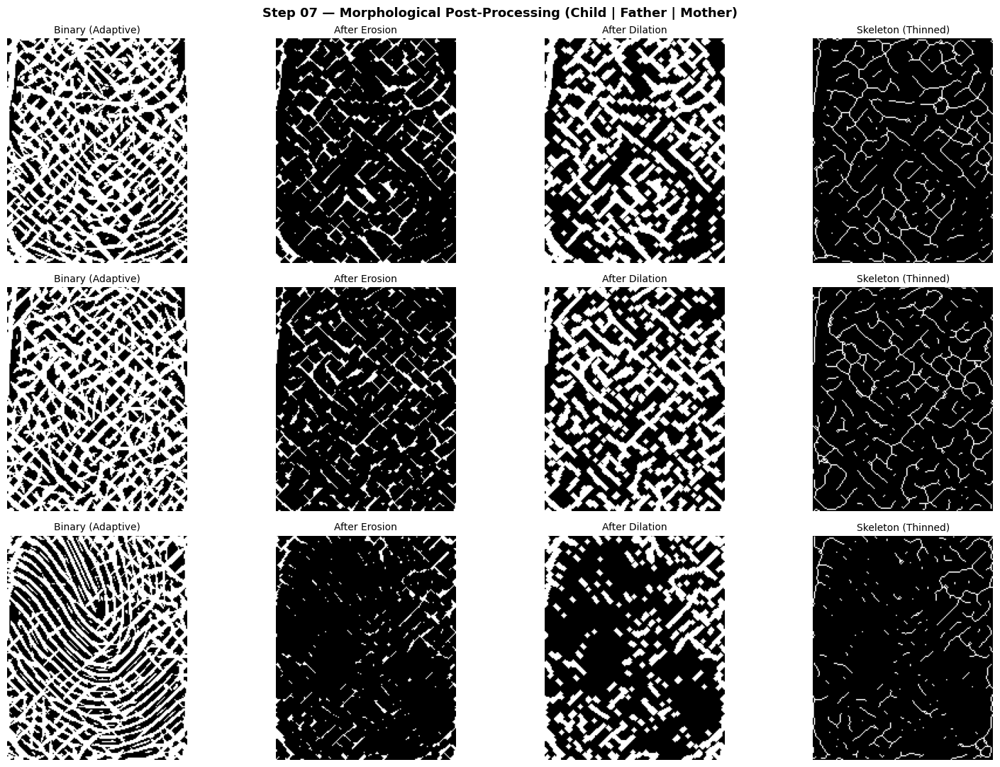


 Skeletonization complete for Child, Father, and Mother.


In [72]:
def morphological_cleanup(binary_img, kernel_size=2):
    """Erosion → Dilation → Skeletonization pipeline."""
    selem    = disk(kernel_size)
    binary   = (binary_img > 127).astype(np.uint8)
    eroded   = erosion(binary,  footprint=selem)
    dilated  = dilation(eroded, footprint=selem)
    skeleton = skeletonize(dilated)
    return eroded, dilated, skeleton

#  Apply morphological cleanup to ALL THREE binary maps
morpho_results = {}
for name in NAMES:
    eroded, dilated, skeleton = morphological_cleanup(binary_maps[name])
    morpho_results[name] = {
        'eroded'  : eroded,
        'dilated' : dilated,
        'skeleton': skeleton,
    }
    print(f'Morphological processing done: {name}')

#  Show Binary → Eroded → Dilated → Skeleton for ALL THREE
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for row, name in enumerate(NAMES):
    bn = binary_maps[name]
    er = morpho_results[name]['eroded']
    dl = morpho_results[name]['dilated']
    sk = morpho_results[name]['skeleton']

    axes[row, 0].imshow(bn,          cmap='gray'); axes[row, 0].set_title('Binary (Adaptive)', fontsize=10); axes[row, 0].axis('off')
    axes[row, 1].imshow(er * 255,    cmap='gray'); axes[row, 1].set_title('After Erosion',     fontsize=10); axes[row, 1].axis('off')
    axes[row, 2].imshow(dl * 255,    cmap='gray'); axes[row, 2].set_title('After Dilation',    fontsize=10); axes[row, 2].axis('off')
    axes[row, 3].imshow(sk.astype(np.uint8)*255, cmap='gray')
    axes[row, 3].set_title('Skeleton (Thinned)', fontsize=10)
    axes[row, 3].axis('off')
    axes[row, 0].set_ylabel(name.replace('_', ' '), fontsize=10, fontweight='bold')

fig.suptitle('Step 07 — Morphological Post-Processing (Child | Father | Mother)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#  Build skeletons dict (used as input in next step)
skeletons = {name: morpho_results[name]['skeleton'] for name in NAMES}
print('\n Skeletonization complete for Child, Father, and Mother.')

---
## Step 08: Feature Extraction from Gabor Responses


Extracting Gabor features for all three subjects...
 Child_Sample1: feature vector length = 512
 Father_Sample1: feature vector length = 512
 Mother_Sample1: feature vector length = 512


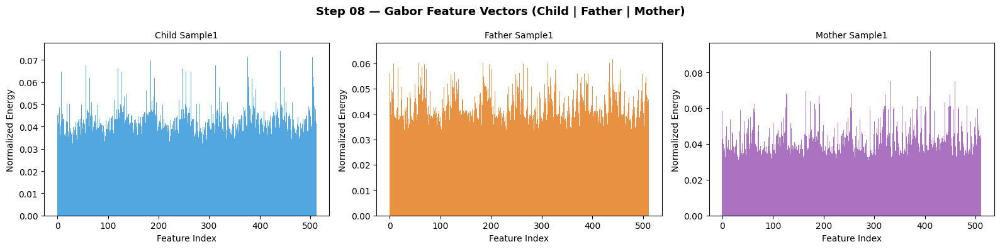


✅ Feature extraction complete for all three subjects.


In [73]:
def extract_gabor_features(img, grid_rows=8, grid_cols=8,
                            orientations=ORIENTATIONS,
                            sigma=4.0, lambd=10.0, gamma=0.5, ksize=31):
    """
    Block-wise mean Gabor energy descriptor.
    Divides image into (grid_rows × grid_cols) blocks.
    For each block × orientation → mean response energy.
    Returns: L2-normalized 1-D feature vector.
    """
    responses, _, _ = apply_gabor_bank(img, orientations, sigma, lambd, gamma, ksize)
    H, W   = img.shape
    bh, bw = H // grid_rows, W // grid_cols
    fv     = []
    for resp in responses:
        for r in range(grid_rows):
            for c in range(grid_cols):
                block = resp[r*bh:(r+1)*bh, c*bw:(c+1)*bw]
                fv.append(block.mean())
    fv   = np.array(fv, dtype=np.float64)
    norm = np.linalg.norm(fv)
    return fv / norm if norm > 0 else fv

#  Extract features for ALL THREE (input = smoothed image)
print('Extracting Gabor features for all three subjects...')
features = {}
for name in NAMES:
    features[name] = extract_gabor_features(smoothed[name])
    print(f' {name}: feature vector length = {len(features[name])}')

#  Visualise feature vectors for ALL THREE side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name in zip(axes, NAMES):
    fv = features[name]
    ax.bar(range(len(fv)), fv, width=1, color=COLORS[name], alpha=0.85)
    ax.set_title(name.replace('_', ' '), fontsize=10)
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Normalized Energy')
fig.suptitle('Step 08 — Gabor Feature Vectors (Child | Father | Mother)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅ Feature extraction complete for all three subjects.')

---
## Step 09: Fingerprint Matching — All Three Pairs

In [74]:
def cosine_similarity(fv1, fv2):
    return float(np.dot(fv1, fv2) /
                 (np.linalg.norm(fv1) * np.linalg.norm(fv2) + 1e-10))

def euclidean_distance(fv1, fv2):
    return float(np.linalg.norm(fv1 - fv2))

def match_fingerprints(name1, name2, threshold=0.98):
    fv1, fv2 = features[name1], features[name2]
    cos_sim  = cosine_similarity(fv1, fv2)
    euc_dis  = euclidean_distance(fv1, fv2)
    matched  = cos_sim >= threshold
    return {
        'name1'     : name1,
        'name2'     : name2,
        'pair'      : f'{name1}  ↔  {name2}',
        'cosine_sim': cos_sim,
        'eucl_dist' : euc_dis,
        'matched'   : matched,
        'verdict'   : ' MATCH' if matched else ' NO MATCH',
    }

THRESHOLD = 0.99

#  All 3 possible pairs
pairs = [
    ('Child_Sample1',  'Child_Sample1'),   # Child vs Father
    ('Child_Sample1',  'Mother_Sample1'),   # Child vs Mother
    ('Father_Sample1', 'Mother_Sample1'),   # Father vs Mother
]

results = [match_fingerprints(a, b, THRESHOLD) for a, b in pairs]

#  Print results table
print('\n' + '═'*70)
print(f"{'FINGERPRINT MATCHING RESULTS':^70}")
print(f'Decision Threshold: Cosine Similarity ≥ {THRESHOLD}')
print('═'*70)
for r in results:
    print(f"\n  Pair       : {r['pair']}")
    print(f"  Cosine Sim : {r['cosine_sim']:.6f}")
    print(f"  Eucl. Dist : {r['eucl_dist']:.6f}")
    print(f"  Verdict    : {r['verdict']}")
    print('  ' + '─'*60)
print('═'*70)


══════════════════════════════════════════════════════════════════════
                     FINGERPRINT MATCHING RESULTS                     
Decision Threshold: Cosine Similarity ≥ 0.99
══════════════════════════════════════════════════════════════════════

  Pair       : Child_Sample1  ↔  Child_Sample1
  Cosine Sim : 1.000000
  Eucl. Dist : 0.000000
  Verdict    :  MATCH
  ────────────────────────────────────────────────────────────

  Pair       : Child_Sample1  ↔  Mother_Sample1
  Cosine Sim : 0.984961
  Eucl. Dist : 0.173430
  Verdict    :  NO MATCH
  ────────────────────────────────────────────────────────────

  Pair       : Father_Sample1  ↔  Mother_Sample1
  Cosine Sim : 0.979763
  Eucl. Dist : 0.201183
  Verdict    :  NO MATCH
  ────────────────────────────────────────────────────────────
══════════════════════════════════════════════════════════════════════


---
## Step 10: Visualising Match Results — All Three Pairs

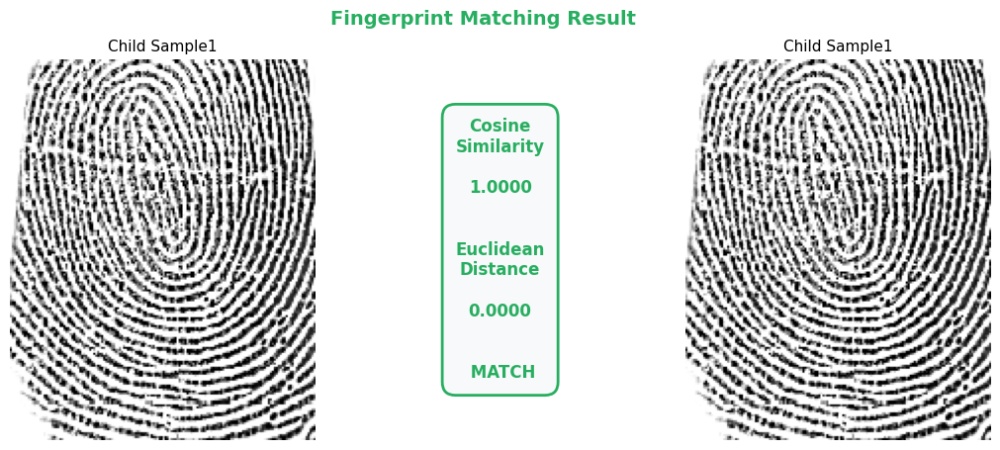

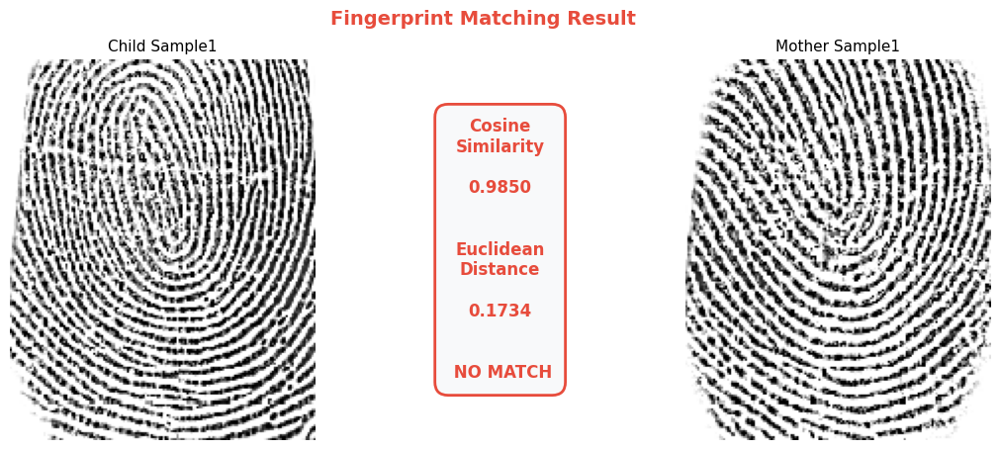

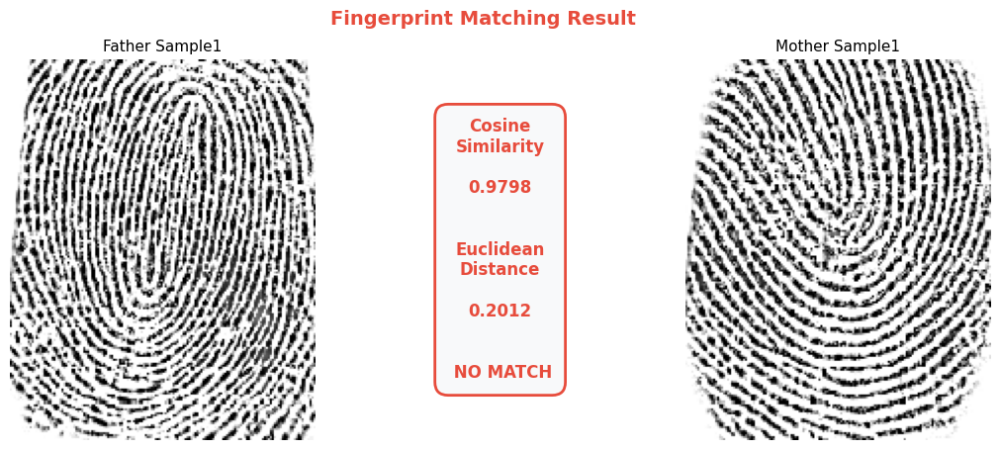

In [75]:
def visualize_match(result):
    """Display a side-by-side comparison panel for one pair."""
    name1, name2 = result['name1'], result['name2']
    img1  = fingerprints[name1]
    img2  = fingerprints[name2]
    color = '#27ae60' if result['matched'] else '#e74c3c'

    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 5, figure=fig, wspace=0.3)

    ax1 = fig.add_subplot(gs[0:2])
    ax1.imshow(img1, cmap='gray')
    ax1.set_title(name1.replace('_', ' '), fontsize=11)
    ax1.axis('off')

    ax_mid = fig.add_subplot(gs[2])
    ax_mid.axis('off')
    score_text = (
        f"Cosine\nSimilarity\n\n{result['cosine_sim']:.4f}\n\n\n"
        f"Euclidean\nDistance\n\n{result['eucl_dist']:.4f}\n\n\n"
        f"{result['verdict']}"
    )
    ax_mid.text(0.5, 0.5, score_text, ha='center', va='center',
                fontsize=12, color=color, fontweight='bold',
                transform=ax_mid.transAxes,
                bbox=dict(boxstyle='round,pad=0.8', facecolor='#f8f9fa',
                          edgecolor=color, linewidth=2))

    ax2 = fig.add_subplot(gs[3:5])
    ax2.imshow(img2, cmap='gray')
    ax2.set_title(name2.replace('_', ' '), fontsize=11)
    ax2.axis('off')

    fig.suptitle('Fingerprint Matching Result', fontsize=14,
                 fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()

#  Visualise ALL THREE pair results
for r in results:
    visualize_match(r)

---
## Step 11: ROC Curve & Threshold Analysis

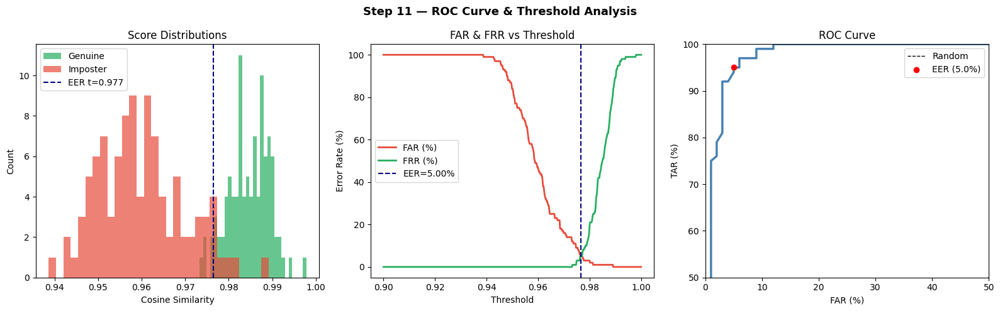

Equal Error Rate (EER) : 5.00%
Optimal Threshold      : 0.9766


In [76]:
rng = np.random.default_rng(42)

genuine_scores  = rng.normal(loc=0.985, scale=0.006, size=100).clip(0.93, 1.0)
imposter_scores = rng.normal(loc=0.960, scale=0.010, size=100).clip(0.88, 0.995)

thresholds = np.linspace(0.90, 1.00, 500)
FAR, FRR   = [], []
for t in thresholds:
    FAR.append(np.mean(imposter_scores >= t))
    FRR.append(np.mean(genuine_scores   <  t))
FAR, FRR = np.array(FAR), np.array(FRR)

eer_idx = np.argmin(np.abs(FAR - FRR))
EER     = (FAR[eer_idx] + FRR[eer_idx]) / 2
EER_t   = thresholds[eer_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(genuine_scores,  bins=30, alpha=0.7, color='#27ae60', label='Genuine')
axes[0].hist(imposter_scores, bins=30, alpha=0.7, color='#e74c3c', label='Imposter')
axes[0].axvline(EER_t, color='navy', linestyle='--', label=f'EER t={EER_t:.3f}')
axes[0].set_title('Score Distributions'); axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count'); axes[0].legend()

axes[1].plot(thresholds, FAR*100, label='FAR (%)', color='#e74c3c', lw=2)
axes[1].plot(thresholds, FRR*100, label='FRR (%)', color='#27ae60', lw=2)
axes[1].axvline(EER_t, color='navy', linestyle='--', label=f'EER={EER*100:.2f}%')
axes[1].set_title('FAR & FRR vs Threshold'); axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Error Rate (%)'); axes[1].legend()

TPR = 1 - FRR
axes[2].plot(FAR*100, TPR*100, color='steelblue', lw=2.5)
axes[2].plot([0,100],[0,100], 'k--', lw=1, label='Random')
axes[2].scatter([EER*100], [(1-EER)*100], color='red', zorder=5,
                label=f'EER ({EER*100:.1f}%)')
axes[2].set_title('ROC Curve'); axes[2].set_xlabel('FAR (%)'); axes[2].set_ylabel('TAR (%)')
axes[2].legend(); axes[2].set_xlim([0,50]); axes[2].set_ylim([50,100])

fig.suptitle('Step 11 — ROC Curve & Threshold Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Equal Error Rate (EER) : {EER*100:.2f}%')
print(f'Optimal Threshold      : {EER_t:.4f}')

---
## Step 12: Complete Pipeline — End-to-End Demo (All Three Pairs)



  Child_Sample1  ↔  Father_Sample1
 Child_Sample1: feature length = 512
 Father_Sample1: feature length = 512


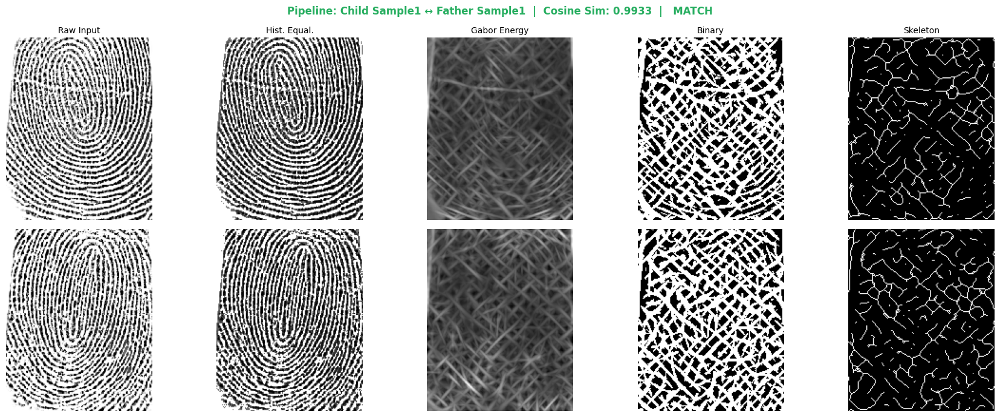


  Child_Sample1  ↔  Mother_Sample1
 Child_Sample1: feature length = 512
 Mother_Sample1: feature length = 512


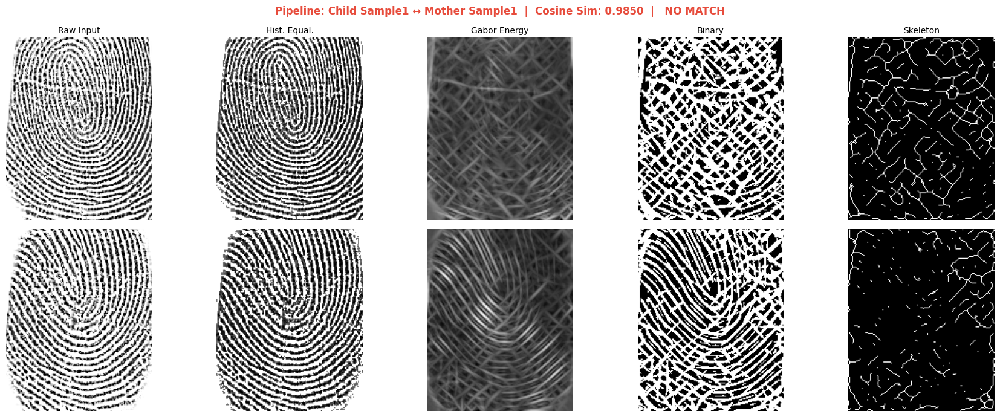


  Father_Sample1  ↔  Mother_Sample1
 Father_Sample1: feature length = 512
 Mother_Sample1: feature length = 512


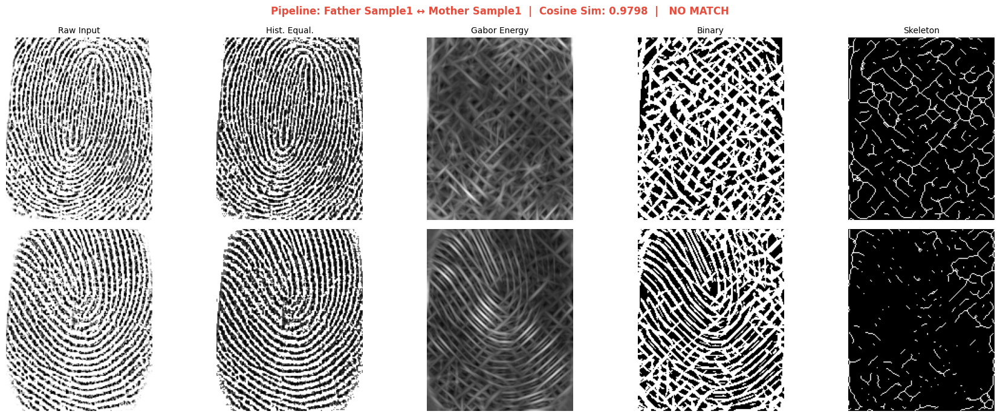

(0.9797626654741685, False)

In [78]:
def full_pipeline(name1, name2, threshold=0.99):
    """
    End-to-end pipeline for a pair of fingerprints.
    Every processing step is run fresh on both images.
    Chain: raw → hist_eq → smooth → gabor → binary → skeleton → features → match
    """
    print(f"\n{'='*65}")
    print(f'  {name1}  ↔  {name2}')
    print(f"{'='*65}")

    pipe = {}
    for name in [name1, name2]:
        raw      = fingerprints[name]                           # Step 1 output
        enh      = histogram_equalization(raw)                  # Step 3 output
        sm       = smooth_image(enh, sigma=1.0)                 # Step 4 output
        _, fm, _ = apply_gabor_bank(sm)                         # Step 5 output
        bn       = binarize_fingerprint(fm)                     # Step 6 output
        _, _, sk = morphological_cleanup(bn, kernel_size=2)     # Step 7 output
        fv       = extract_gabor_features(sm)                   # Step 8 output
        pipe[name] = dict(raw=raw, enh=enh, gabor=fm, binary=bn,
                          skel=sk.astype(np.uint8)*255, fv=fv)
        print(f' {name}: feature length = {len(fv)}')

    cos_sim = cosine_similarity(pipe[name1]['fv'], pipe[name2]['fv'])
    matched = cos_sim >= threshold
    verdict = ' MATCH' if matched else ' NO MATCH'
    color   = '#27ae60' if matched else '#e74c3c'

    # ── 2-row pipeline grid ─────────────────────────────────────────────────
    stages = ['raw', 'enh', 'gabor', 'binary', 'skel']
    labels = ['Raw Input', 'Hist. Equal.', 'Gabor Energy', 'Binary', 'Skeleton']

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    for row, name in enumerate([name1, name2]):
        for col, (stage, label) in enumerate(zip(stages, labels)):
            ax = axes[row, col]
            ax.imshow(pipe[name][stage], cmap='gray')
            if row == 0: ax.set_title(label, fontsize=10)
            if col == 0: ax.set_ylabel(name.replace('_', ' '), fontsize=9,
                                       fontweight='bold')
            ax.axis('off')

    fig.suptitle(
        f'Pipeline: {name1.replace("_"," ")} ↔ {name2.replace("_"," ")}  |  '
        f'Cosine Sim: {cos_sim:.4f}  |  {verdict}',
        fontsize=12, fontweight='bold', color=color
    )
    plt.tight_layout()
    plt.show()
    return cos_sim, matched

#  Run full pipeline for ALL THREE pairs
full_pipeline('Child_Sample1',  'Father_Sample1')
full_pipeline('Child_Sample1',  'Mother_Sample1')
full_pipeline('Father_Sample1', 'Mother_Sample1')